In [4]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Image

In [ ]:
PROJECT_ROOT = Path("..").resolve()

# Find available V4 result files
for p in (PROJECT_ROOT / "results" / "v4").rglob("*.json"):
    print(p)

/Users/abhra/Downloads/AI-ML/Resume/BraTS/results/v4/v4_test_126_patients.json


In [5]:
RESULTS_FILE = Path(
    "../results/v4/v4_test_126_patients.json"
)

with open(RESULTS_FILE) as f:
    data = json.load(f)

results = pd.DataFrame(data["results"])

print("Patients:", len(results))
display(results.head())

Patients: 126


,patient,dice,iou,patches,time_seconds
0,BraTS-GLI-01666-000,0.886016,0.795358,36,23.804365
1,BraTS-GLI-01518-000,0.928116,0.865874,36,23.629714
2,BraTS-GLI-01497-000,0.488818,0.323468,36,24.539226
3,BraTS-GLI-01397-000,0.867503,0.766009,36,24.821629
4,BraTS-GLI-00291-000,0.864194,0.760863,36,24.681287


In [6]:
print(f"Mean Dice   : {results['dice'].mean():.4f}")
print(f"Std Dice    : {results['dice'].std():.4f}")
print(f"Median Dice : {results['dice'].median():.4f}")

print()

print(f"Mean IoU    : {results['iou'].mean():.4f}")
print(f"Std IoU     : {results['iou'].std():.4f}")

print()

print(f"Best Dice   : {results['dice'].max():.4f}")
print(f"Worst Dice  : {results['dice'].min():.4f}")

Mean Dice   : 0.8079
Std Dice    : 0.1909
Median Dice : 0.8852

Mean IoU    : 0.7111
Std IoU     : 0.2125

Best Dice   : 0.9689
Worst Dice  : 0.0075


In [7]:
results_sorted = results.sort_values(
    "dice"
).reset_index(drop=True)

print("WORST 5")
display(results_sorted.head(5))

print("BEST 5")
display(results_sorted.tail(5).sort_values(
    "dice",
    ascending=False
))

WORST 5


,patient,dice,iou,patches,time_seconds
0,BraTS-GLI-00613-000,0.007519,0.003774,36,24.666873
1,BraTS-GLI-00621-000,0.073393,0.038094,36,25.088285
2,BraTS-GLI-01507-000,0.161760,0.087997,36,24.657820
3,BraTS-GLI-01504-000,0.289477,0.169233,36,24.278586
4,BraTS-GLI-01480-000,0.313842,0.186128,36,24.573093


BEST 5


,patient,dice,iou,patches,time_seconds
125,BraTS-GLI-00768-000,0.968862,0.939604,36,24.310167
124,BraTS-GLI-00789-000,0.965577,0.933445,36,24.531832
123,BraTS-GLI-01396-000,0.965549,0.933393,36,24.540874
122,BraTS-GLI-00823-000,0.960352,0.923728,36,24.271143
121,BraTS-GLI-01537-000,0.956762,0.917107,36,24.218216


In [8]:
median_dice = results["dice"].median()

median_idx = (
    results["dice"] - median_dice
).abs().idxmin()

median_patient = results.loc[
    median_idx
]

print(
    "Median patient:"
)

print(
    median_patient
)

Median patient:
patient         BraTS-GLI-01666-000
dice                       0.886016
iou                        0.795358
patches                          36
time_seconds              23.804365
Name: 0, dtype: object


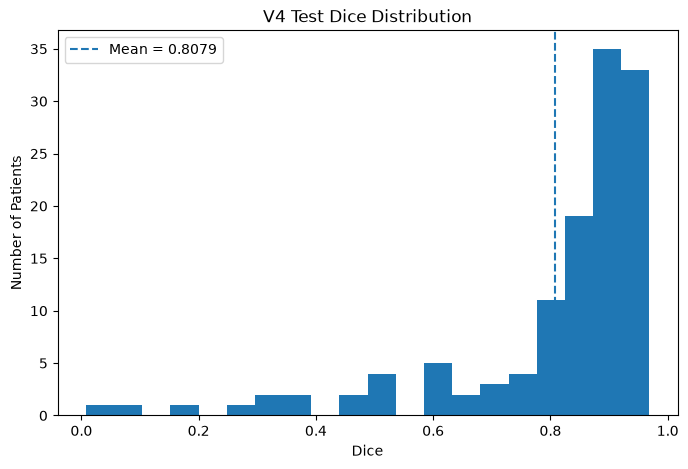

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(
    results["dice"],
    bins=20
)

plt.axvline(
    results["dice"].mean(),
    linestyle="--",
    label=f"Mean = {results['dice'].mean():.4f}"
)

plt.xlabel("Dice")
plt.ylabel("Number of Patients")
plt.title("V4 Test Dice Distribution")
plt.legend()

plt.show()

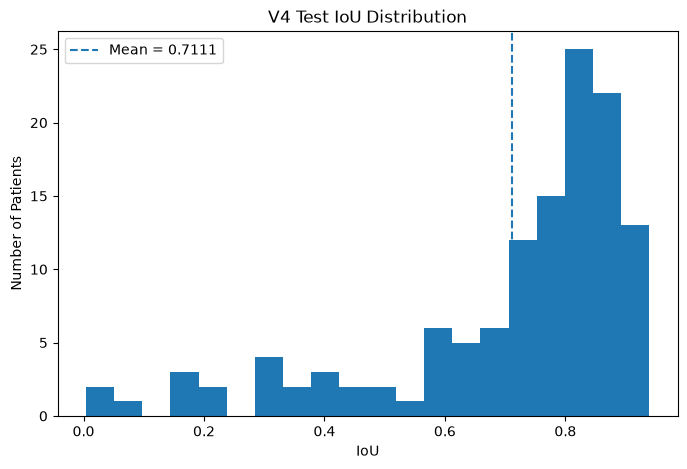

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    results["iou"],
    bins=20
)

plt.axvline(
    results["iou"].mean(),
    linestyle="--",
    label=f"Mean = {results['iou'].mean():.4f}"
)

plt.xlabel("IoU")
plt.ylabel("Number of Patients")
plt.title("V4 Test IoU Distribution")
plt.legend()

plt.show()

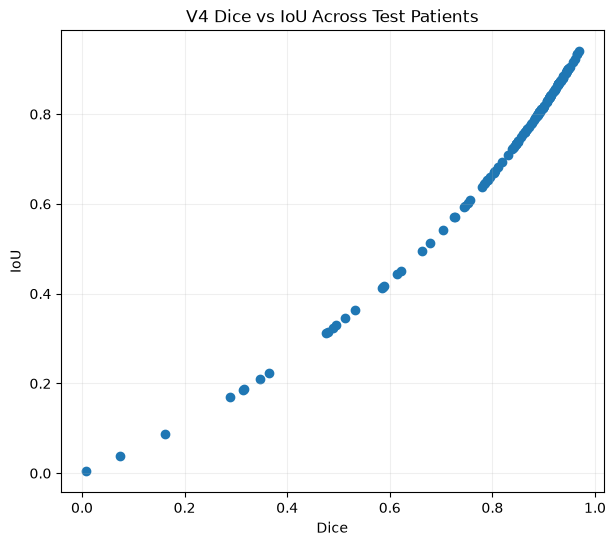

In [11]:
plt.figure(figsize=(7, 6))

plt.scatter(
    results["dice"],
    results["iou"]
)

plt.xlabel("Dice")
plt.ylabel("IoU")
plt.title("V4 Dice vs IoU Across Test Patients")

plt.grid(alpha=0.2)

plt.show()

In [12]:
best_patient = results.loc[
    results["dice"].idxmax()
]

worst_patient = results.loc[
    results["dice"].idxmin()
]

median_patient = results.loc[
    (results["dice"] - results["dice"].median()).abs().idxmin()
]

print("BEST")
print(best_patient)

print("\nMEDIAN")
print(median_patient)

print("\nWORST")
print(worst_patient)

BEST
patient         BraTS-GLI-00768-000
dice                       0.968862
iou                        0.939604
patches                          36
time_seconds              24.310167
Name: 42, dtype: object

MEDIAN
patient         BraTS-GLI-01666-000
dice                       0.886016
iou                        0.795358
patches                          36
time_seconds              23.804365
Name: 0, dtype: object

WORST
patient         BraTS-GLI-00613-000
dice                       0.007519
iou                        0.003774
patches                          36
time_seconds              24.666873
Name: 28, dtype: object


In [13]:
WORST_PATIENT = "BraTS-GLI-00613-000"
MEDIAN_PATIENT = median_patient["patient"]
BEST_PATIENT = "BraTS-GLI-00768-000"

print("Worst :", WORST_PATIENT)
print("Median:", MEDIAN_PATIENT)
print("Best  :", BEST_PATIENT)

Worst : BraTS-GLI-00613-000
Median: BraTS-GLI-01666-000
Best  : BraTS-GLI-00768-000


In [14]:
import sys
import torch

REPO = Path("..").resolve()

V4_SRC = (
    REPO
    / "src"
    / "v4_3d_unet_model"
)

if str(V4_SRC) not in sys.path:
    sys.path.insert(0, str(V4_SRC))

from unet_3d import UNet3D
import preprocess_v4


RAW_DIR = (
    REPO
    / "data"
    / "raw"
    / "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
)

CHECKPOINT = (
    REPO
    / "models"
    / "v4"
    / "epoch_5.pt"
)

preprocess_v4.RAW_DIR = RAW_DIR

device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

model = UNet3D(
    in_channels=4,
    out_channels=1
)

checkpoint = torch.load(
    CHECKPOINT,
    map_location="cpu"
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Device:", device)
print("Checkpoint:", CHECKPOINT)
print("Patch size:", preprocess_v4.PATCH_SIZE)
print("Stride:", preprocess_v4.STRIDE)

Device: mps
Checkpoint: /Users/abhra/Downloads/AI-ML/Resume/BraTS/models/v4/epoch_5.pt
Patch size: (64, 128, 128)
Stride: (32, 64, 64)


# Worst Case Analysis

In [15]:
patient_id = WORST_PATIENT

mri, target = preprocess_v4.load_patient(
    patient_id
)

print("Patient:", patient_id)
print("MRI shape:", mri.shape)
print("Target shape:", target.shape)
print("Tumor voxels:", int((target > 0).sum()))

Patient: BraTS-GLI-00613-000
MRI shape: (4, 155, 240, 240)
Target shape: (155, 240, 240)
Tumor voxels: 77497


In [16]:
mri_norm = mri.copy()

for channel in range(mri_norm.shape[0]):
    mri_norm[channel] = preprocess_v4.normalize_volume(
        mri_norm[channel]
    )

print("Normalized MRI:", mri_norm.shape)

for channel in range(4):
    print(
        f"Channel {channel}: "
        f"min={mri_norm[channel].min():.3f}, "
        f"max={mri_norm[channel].max():.3f}, "
        f"mean={mri_norm[channel].mean():.3f}, "
        f"std={mri_norm[channel].std():.3f}"
    )

Normalized MRI: (4, 155, 240, 240)
Channel 0: min=-3.411, max=4.853, mean=-0.000, std=0.388
Channel 1: min=-2.806, max=11.959, mean=0.000, std=0.388
Channel 2: min=-1.893, max=4.399, mean=-0.000, std=0.388
Channel 3: min=-2.545, max=3.491, mean=0.000, std=0.388


In [17]:
pd, ph, pw = preprocess_v4.PATCH_SIZE
sd, sh, sw = preprocess_v4.STRIDE

_, depth, height, width = mri_norm.shape

z_starts = preprocess_v4.get_patch_starts(
    depth, pd, sd
)

y_starts = preprocess_v4.get_patch_starts(
    height, ph, sh
)

x_starts = preprocess_v4.get_patch_starts(
    width, pw, sw
)

print("Patch grid:")
print("Z:", len(z_starts))
print("Y:", len(y_starts))
print("X:", len(x_starts))
print(
    "Total patches:",
    len(z_starts) * len(y_starts) * len(x_starts)
)

Patch grid:
Z: 4
Y: 3
X: 3
Total patches: 36


In [18]:
probability_sum = np.zeros(
    (depth, height, width),
    dtype=np.float32
)

count_map = np.zeros(
    (depth, height, width),
    dtype=np.float32
)

patch_count = 0

with torch.no_grad():

    for z in z_starts:
        for y in y_starts:
            for x in x_starts:

                patch = mri_norm[
                    :,
                    z:z + pd,
                    y:y + ph,
                    x:x + pw
                ]

                tensor = torch.from_numpy(
                    patch.astype(np.float32)
                ).unsqueeze(0).to(device)

                logits = model(tensor)

                probability = (
                    torch.sigmoid(logits)
                    .squeeze()
                    .detach()
                    .cpu()
                    .numpy()
                )

                probability_sum[
                    z:z + pd,
                    y:y + ph,
                    x:x + pw
                ] += probability

                count_map[
                    z:z + pd,
                    y:y + ph,
                    x:x + pw
                ] += 1

                patch_count += 1

print("Inference complete.")
print("Patches processed:", patch_count)

Inference complete.
Patches processed: 36


In [19]:
probability_volume = (
    probability_sum
    / np.maximum(count_map, 1)
)

prediction = (
    probability_volume >= 0.5
).astype(np.uint8)

ground_truth = (
    target > 0
).astype(np.uint8)

print("Prediction shape:", prediction.shape)
print("Ground truth shape:", ground_truth.shape)

print(
    "Predicted tumor voxels:",
    int(prediction.sum())
)

print(
    "Ground-truth tumor voxels:",
    int(ground_truth.sum())
)

Prediction shape: (155, 240, 240)
Ground truth shape: (155, 240, 240)
Predicted tumor voxels: 437
Ground-truth tumor voxels: 77497


In [20]:
print("Probability statistics:")
print("Min :", probability_volume.min())
print("Max :", probability_volume.max())
print("Mean:", probability_volume.mean())
print("Std :", probability_volume.std())

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}%:",
        np.percentile(probability_volume, p)
    )

Probability statistics:
Min : 0.044580627
Max : 0.7090583
Mean: 0.082897656
Std : 0.009580454

Percentiles:
 50.0%: 0.082248315
 75.0%: 0.08376107
 90.0%: 0.08900468
 95.0%: 0.09347599
 99.0%: 0.106099665
 99.5%: 0.11596536
 99.9%: 0.18237618


In [21]:
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

print(
    f"{'Threshold':>10} "
    f"{'Pred Voxels':>15} "
    f"{'Dice':>10} "
    f"{'IoU':>10}"
)

for threshold in thresholds:

    pred = (
        probability_volume >= threshold
    ).astype(np.uint8)

    intersection = (
        pred * ground_truth
    ).sum()

    dice = (
        2 * intersection + 1e-6
    ) / (
        pred.sum()
        + ground_truth.sum()
        + 1e-6
    )

    union = (
        pred
        + ground_truth
        - pred * ground_truth
    ).sum()

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    print(
        f"{threshold:10.2f} "
        f"{int(pred.sum()):15,d} "
        f"{dice:10.4f} "
        f"{iou:10.4f}"
    )

 Threshold     Pred Voxels       Dice        IoU
      0.10         163,942     0.3679     0.2254
      0.15          14,684     0.2392     0.1359
      0.20           7,210     0.1285     0.0687
      0.25           4,627     0.0860     0.0450
      0.30           3,101     0.0596     0.0307
      0.40           1,318     0.0254     0.0129
      0.50             437     0.0075     0.0038


In [23]:
import pandas as pd

threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.01):

    pred = (
        probability_volume >= threshold
    ).astype(np.uint8)

    intersection = (
        pred * ground_truth
    ).sum()

    dice = (
        2 * intersection + 1e-6
    ) / (
        pred.sum()
        + ground_truth.sum()
        + 1e-6
    )

    union = (
        pred
        + ground_truth
        - pred * ground_truth
    ).sum()

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    threshold_results.append(
        {
            "threshold": threshold,
            "dice": dice,
            "iou": iou,
            "pred_voxels": int(pred.sum())
        }
    )

threshold_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_df.loc[
    threshold_df["dice"].idxmax()
]

display(
    threshold_df.sort_values(
        "dice",
        ascending=False
    ).head(10)
)

print(
    "Best threshold:",
    best_threshold_row["threshold"]
)

print(
    "Best Dice:",
    best_threshold_row["dice"]
)

,threshold,dice,iou,pred_voxels
6,0.11,0.402210,0.251729,65672
5,0.10,0.367878,0.225398,163942
7,0.12,0.364964,0.223214,35380
8,0.13,0.319201,0.189910,23242
9,0.14,0.277588,0.161162,17889
10,0.15,0.239225,0.135863,14684
11,0.16,0.207026,0.115465,12347
12,0.17,0.181174,0.099610,10573
13,0.18,0.160643,0.087337,9217
4,0.09,0.157303,0.085365,774403


Best threshold: 0.11000000000000001
Best Dice: 0.4022099756273899


Selected slice: 112
Ground-truth tumor voxels: 2006


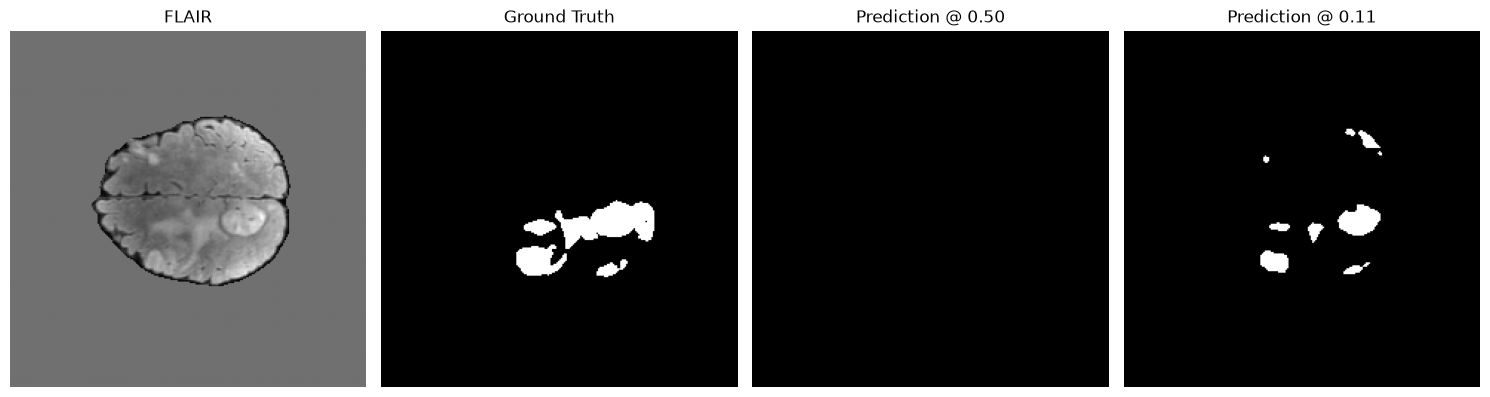

In [24]:
# Select the slice containing the most ground-truth tumor voxels
tumor_per_slice = ground_truth.sum(axis=(1, 2))

z = int(np.argmax(tumor_per_slice))

print("Selected slice:", z)
print("Ground-truth tumor voxels:", int(tumor_per_slice[z]))

fig = plt.figure(figsize=(15, 4))

ax1 = fig.add_subplot(1, 4, 1)
ax1.imshow(mri_norm[3, z], cmap="gray")
ax1.set_title("FLAIR")
ax1.axis("off")

ax2 = fig.add_subplot(1, 4, 2)
ax2.imshow(ground_truth[z], cmap="gray")
ax2.set_title("Ground Truth")
ax2.axis("off")

ax3 = fig.add_subplot(1, 4, 3)
ax3.imshow(prediction[z], cmap="gray")
ax3.set_title("Prediction @ 0.50")
ax3.axis("off")

diagnostic_prediction = (
    probability_volume >= 0.11
).astype(np.uint8)

ax4 = fig.add_subplot(1, 4, 4)
ax4.imshow(diagnostic_prediction[z], cmap="gray")
ax4.set_title("Prediction @ 0.11")
ax4.axis("off")

plt.tight_layout()
plt.show()

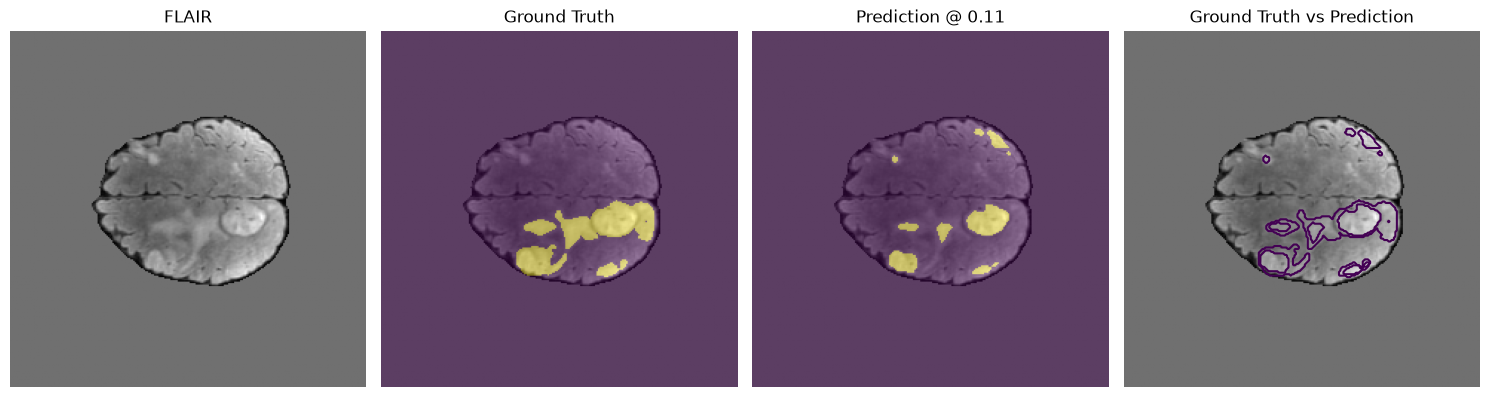

In [25]:
fig = plt.figure(figsize=(15, 4))

# FLAIR
ax1 = fig.add_subplot(1, 4, 1)
ax1.imshow(mri_norm[3, z], cmap="gray")
ax1.set_title("FLAIR")
ax1.axis("off")

# Ground truth
ax2 = fig.add_subplot(1, 4, 2)
ax2.imshow(mri_norm[3, z], cmap="gray")
ax2.imshow(
    ground_truth[z],
    alpha=0.45
)
ax2.set_title("Ground Truth")
ax2.axis("off")

# Prediction
ax3 = fig.add_subplot(1, 4, 3)
ax3.imshow(mri_norm[3, z], cmap="gray")
ax3.imshow(
    diagnostic_prediction[z],
    alpha=0.45
)
ax3.set_title("Prediction @ 0.11")
ax3.axis("off")

# Both masks
ax4 = fig.add_subplot(1, 4, 4)
ax4.imshow(mri_norm[3, z], cmap="gray")
ax4.contour(
    ground_truth[z],
    levels=[0.5],
    linewidths=1.5
)
ax4.contour(
    diagnostic_prediction[z],
    levels=[0.5],
    linewidths=1.5
)
ax4.set_title("Ground Truth vs Prediction")
ax4.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# Calculate Dice for every tumor-containing slice
slice_results = []

for z_idx in range(ground_truth.shape[0]):

    gt = ground_truth[z_idx]
    pred = diagnostic_prediction[z_idx]

    gt_voxels = gt.sum()

    if gt_voxels == 0:
        continue

    intersection = (gt * pred).sum()

    dice = (
        2 * intersection + 1e-6
    ) / (
        gt.sum() + pred.sum() + 1e-6
    )

    slice_results.append({
        "slice": z_idx,
        "gt_voxels": int(gt.sum()),
        "pred_voxels": int(pred.sum()),
        "dice": float(dice)
    })

slice_df = pd.DataFrame(slice_results)

print("Tumor-containing slices:", len(slice_df))

display(
    slice_df.sort_values("dice").head(10)
)

Tumor-containing slices: 66


,slice,gt_voxels,pred_voxels,dice
4,81,100,159,3.861004e-09
0,77,6,224,4.347826e-09
3,80,73,157,4.347826e-09
2,79,47,164,4.739336e-09
1,78,25,184,4.784689e-09
64,141,199,1,5.000000e-09
65,142,68,0,1.470588e-08
62,139,485,20,5.148515e-02
61,138,647,21,5.988024e-02
63,140,316,12,6.707317e-02


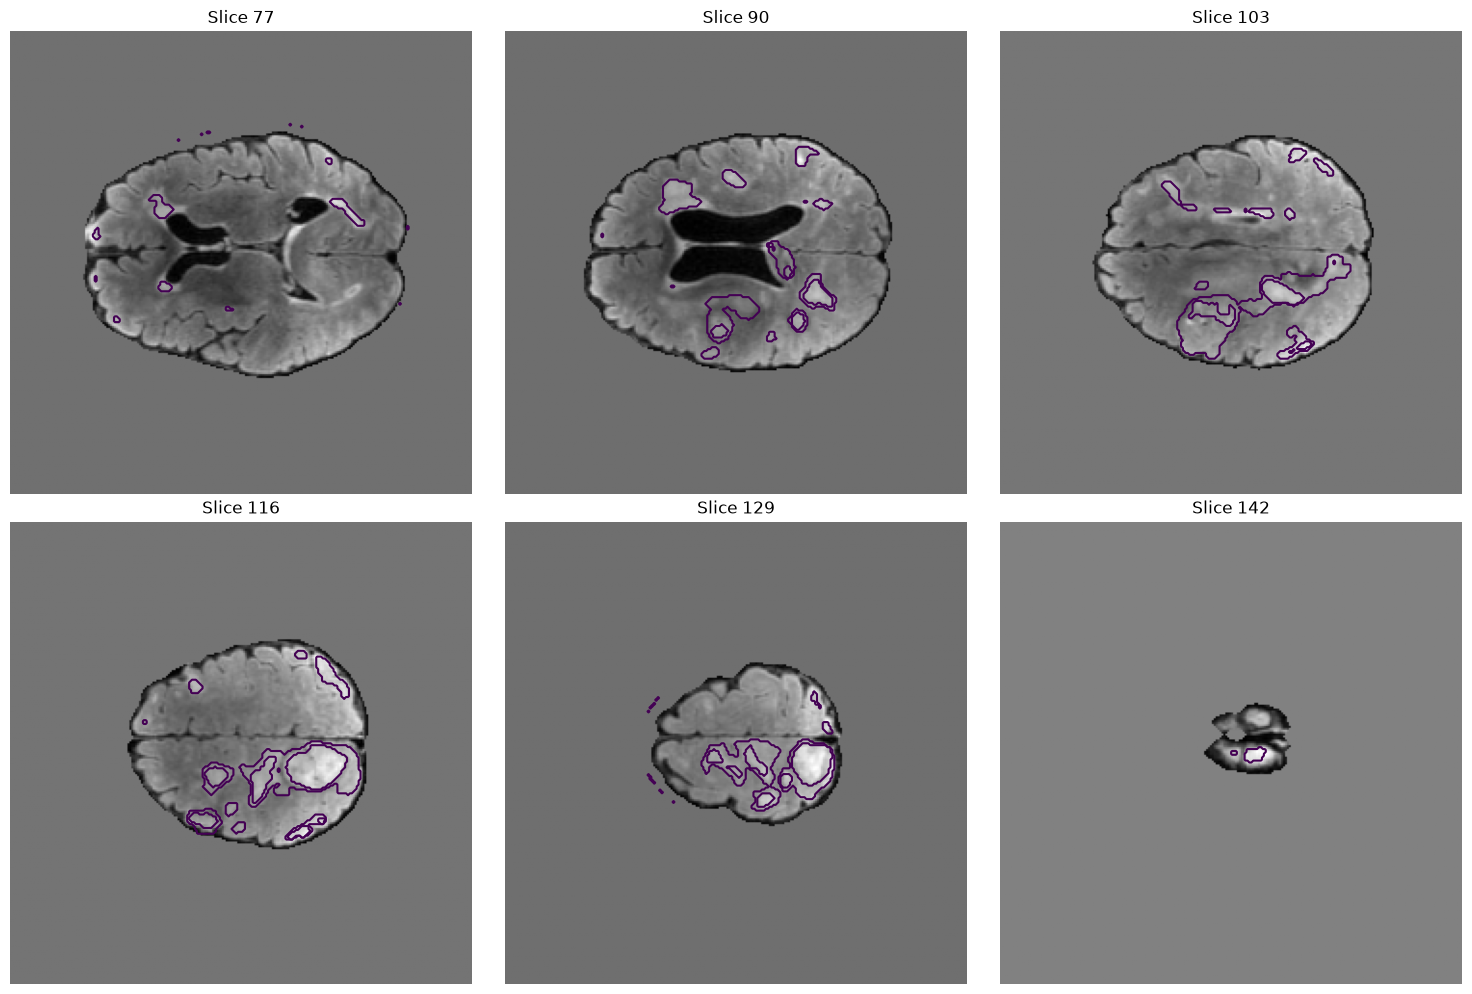

In [27]:
# Pick 6 tumor-containing slices spread across the tumor
slice_indices = np.linspace(
    slice_df["slice"].min(),
    slice_df["slice"].max(),
    6,
    dtype=int
)

fig = plt.figure(figsize=(15, 10))

for i, z_idx in enumerate(slice_indices):

    ax = fig.add_subplot(2, 3, i + 1)

    ax.imshow(
        mri_norm[3, z_idx],
        cmap="gray"
    )

    ax.contour(
        ground_truth[z_idx],
        levels=[0.5],
        linewidths=1.5
    )

    ax.contour(
        diagnostic_prediction[z_idx],
        levels=[0.5],
        linewidths=1.5
    )

    ax.set_title(
        f"Slice {z_idx}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Best Case Analysis

In [28]:
patient_id = BEST_PATIENT

mri_best, target_best = preprocess_v4.load_patient(
    patient_id
)

mri_best = mri_best.copy()

for channel in range(mri_best.shape[0]):
    mri_best[channel] = preprocess_v4.normalize_volume(
        mri_best[channel]
    )

gt_best = (target_best > 0).astype(np.uint8)

print("Patient:", patient_id)
print("MRI shape:", mri_best.shape)
print("Tumor voxels:", int(gt_best.sum()))

Patient: BraTS-GLI-00768-000
MRI shape: (4, 155, 240, 240)
Tumor voxels: 109201


In [29]:
pd, ph, pw = preprocess_v4.PATCH_SIZE
sd, sh, sw = preprocess_v4.STRIDE

_, depth_b, height_b, width_b = mri_best.shape

z_starts_b = preprocess_v4.get_patch_starts(
    depth_b, pd, sd
)

y_starts_b = preprocess_v4.get_patch_starts(
    height_b, ph, sh
)

x_starts_b = preprocess_v4.get_patch_starts(
    width_b, pw, sw
)

print("Patch grid:")
print("Z:", len(z_starts_b))
print("Y:", len(y_starts_b))
print("X:", len(x_starts_b))

print(
    "Total patches:",
    len(z_starts_b)
    * len(y_starts_b)
    * len(x_starts_b)
)

Patch grid:
Z: 4
Y: 3
X: 3
Total patches: 36


In [30]:
probability_sum_best = np.zeros(
    (depth_b, height_b, width_b),
    dtype=np.float32
)

count_map_best = np.zeros(
    (depth_b, height_b, width_b),
    dtype=np.float32
)

patch_count_best = 0

with torch.no_grad():

    for z in z_starts_b:
        for y in y_starts_b:
            for x in x_starts_b:

                patch = mri_best[
                    :,
                    z:z + pd,
                    y:y + ph,
                    x:x + pw
                ]

                tensor = torch.from_numpy(
                    patch.astype(np.float32)
                ).unsqueeze(0).to(device)

                logits = model(tensor)

                probability = (
                    torch.sigmoid(logits)
                    .squeeze()
                    .detach()
                    .cpu()
                    .numpy()
                )

                probability_sum_best[
                    z:z + pd,
                    y:y + ph,
                    x:x + pw
                ] += probability

                count_map_best[
                    z:z + pd,
                    y:y + ph,
                    x:x + pw
                ] += 1

                patch_count_best += 1

print("Inference complete.")
print("Patches processed:", patch_count_best)

Inference complete.
Patches processed: 36


In [31]:
probability_volume_best = (
    probability_sum_best
    / np.maximum(count_map_best, 1)
)

prediction_best = (
    probability_volume_best >= 0.5
).astype(np.uint8)

print("Prediction shape:", prediction_best.shape)

print(
    "Predicted tumor voxels:",
    int(prediction_best.sum())
)

print(
    "Ground-truth tumor voxels:",
    int(gt_best.sum())
)

print("\nProbability statistics:")
print("Min :", probability_volume_best.min())
print("Max :", probability_volume_best.max())
print("Mean:", probability_volume_best.mean())
print("Std :", probability_volume_best.std())

Prediction shape: (155, 240, 240)
Predicted tumor voxels: 104939
Ground-truth tumor voxels: 109201

Probability statistics:
Min : 0.026309306
Max : 0.99542075
Mean: 0.09308664
Std : 0.09259671


Selected slice: 92
Ground-truth tumor voxels: 3136


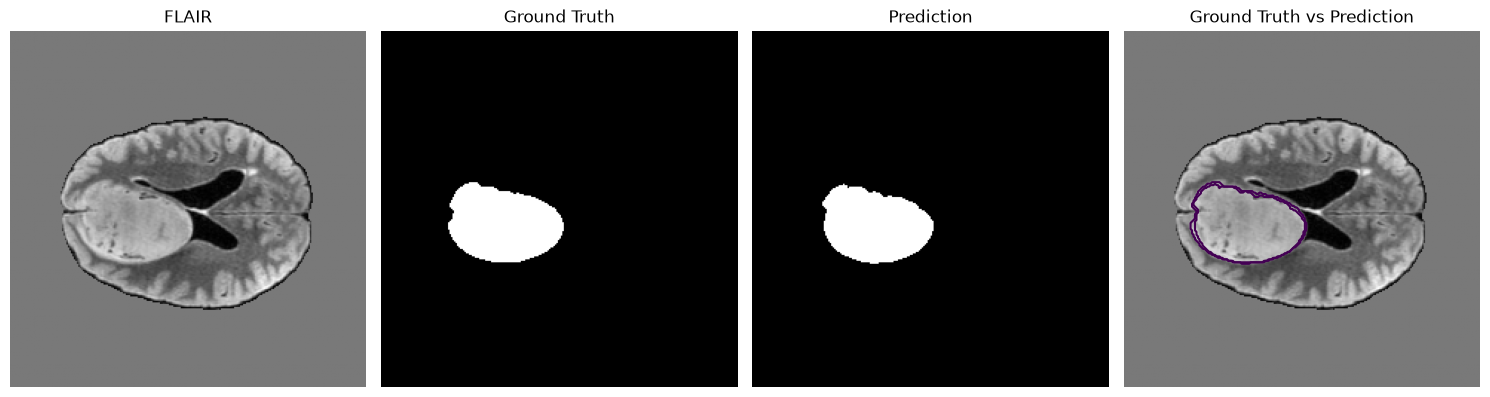

In [32]:
tumor_per_slice_best = gt_best.sum(axis=(1, 2))

z_best = int(
    np.argmax(tumor_per_slice_best)
)

print("Selected slice:", z_best)
print(
    "Ground-truth tumor voxels:",
    int(tumor_per_slice_best[z_best])
)

fig = plt.figure(figsize=(15, 4))

ax1 = fig.add_subplot(1, 4, 1)
ax1.imshow(
    mri_best[3, z_best],
    cmap="gray"
)
ax1.set_title("FLAIR")
ax1.axis("off")

ax2 = fig.add_subplot(1, 4, 2)
ax2.imshow(
    gt_best[z_best],
    cmap="gray"
)
ax2.set_title("Ground Truth")
ax2.axis("off")

ax3 = fig.add_subplot(1, 4, 3)
ax3.imshow(
    prediction_best[z_best],
    cmap="gray"
)
ax3.set_title("Prediction")
ax3.axis("off")

ax4 = fig.add_subplot(1, 4, 4)
ax4.imshow(
    mri_best[3, z_best],
    cmap="gray"
)
ax4.contour(
    gt_best[z_best],
    levels=[0.5],
    linewidths=1.5
)
ax4.contour(
    prediction_best[z_best],
    levels=[0.5],
    linewidths=1.5
)
ax4.set_title("Ground Truth vs Prediction")
ax4.axis("off")

plt.tight_layout()
plt.show()

In [33]:
patient_id = MEDIAN_PATIENT

mri_med, target_med = preprocess_v4.load_patient(
    patient_id
)

mri_med = mri_med.copy()

for channel in range(mri_med.shape[0]):
    mri_med[channel] = preprocess_v4.normalize_volume(
        mri_med[channel]
    )

gt_med = (target_med > 0).astype(np.uint8)

print("Patient:", patient_id)
print("MRI shape:", mri_med.shape)
print("Tumor voxels:", int(gt_med.sum()))

Patient: BraTS-GLI-01666-000
MRI shape: (4, 155, 240, 240)
Tumor voxels: 135746


# Median Case Analysis

In [34]:
_, depth_m, height_m, width_m = mri_med.shape

z_starts_m = preprocess_v4.get_patch_starts(
    depth_m,
    pd,
    sd
)

y_starts_m = preprocess_v4.get_patch_starts(
    height_m,
    ph,
    sh
)

x_starts_m = preprocess_v4.get_patch_starts(
    width_m,
    pw,
    sw
)

print("Patch grid:")
print("Z:", len(z_starts_m))
print("Y:", len(y_starts_m))
print("X:", len(x_starts_m))

print(
    "Total patches:",
    len(z_starts_m)
    * len(y_starts_m)
    * len(x_starts_m)
)

Patch grid:
Z: 4
Y: 3
X: 3
Total patches: 36


In [35]:
probability_sum_med = np.zeros(
    (depth_m, height_m, width_m),
    dtype=np.float32
)

count_map_med = np.zeros(
    (depth_m, height_m, width_m),
    dtype=np.float32
)

with torch.no_grad():
    for z in z_starts_m:
        for y in y_starts_m:
            for x in x_starts_m:

                patch = mri_med[
                    :,
                    z:z + pd,
                    y:y + ph,
                    x:x + pw
                ]

                tensor = torch.from_numpy(
                    patch.astype(np.float32)
                ).unsqueeze(0).to(device)

                probability = torch.sigmoid(
                    model(tensor)
                ).squeeze().cpu().numpy()

                probability_sum_med[
                    z:z + pd,
                    y:y + ph,
                    x:x + pw
                ] += probability

                count_map_med[
                    z:z + pd,
                    y:y + ph,
                    x:x + pw
                ] += 1

probability_med = (
    probability_sum_med /
    np.maximum(count_map_med, 1)
)

prediction_med = (
    probability_med >= 0.5
).astype(np.uint8)

print("Inference complete")
print("Predicted voxels:", int(prediction_med.sum()))
print("GT voxels:", int(gt_med.sum()))

Inference complete
Predicted voxels: 112762
GT voxels: 135746


In [36]:
intersection = (
    prediction_med * gt_med
).sum()

median_dice = (
    2 * intersection + 1e-6
) / (
    prediction_med.sum()
    + gt_med.sum()
    + 1e-6
)

union = (
    prediction_med
    + gt_med
    - prediction_med * gt_med
).sum()

median_iou = (
    intersection + 1e-6
) / (
    union + 1e-6
)

print("Patient:", MEDIAN_PATIENT)
print(f"Dice: {median_dice:.4f}")
print(f"IoU:  {median_iou:.4f}")

Patient: BraTS-GLI-01666-000
Dice: 0.8860
IoU:  0.7954


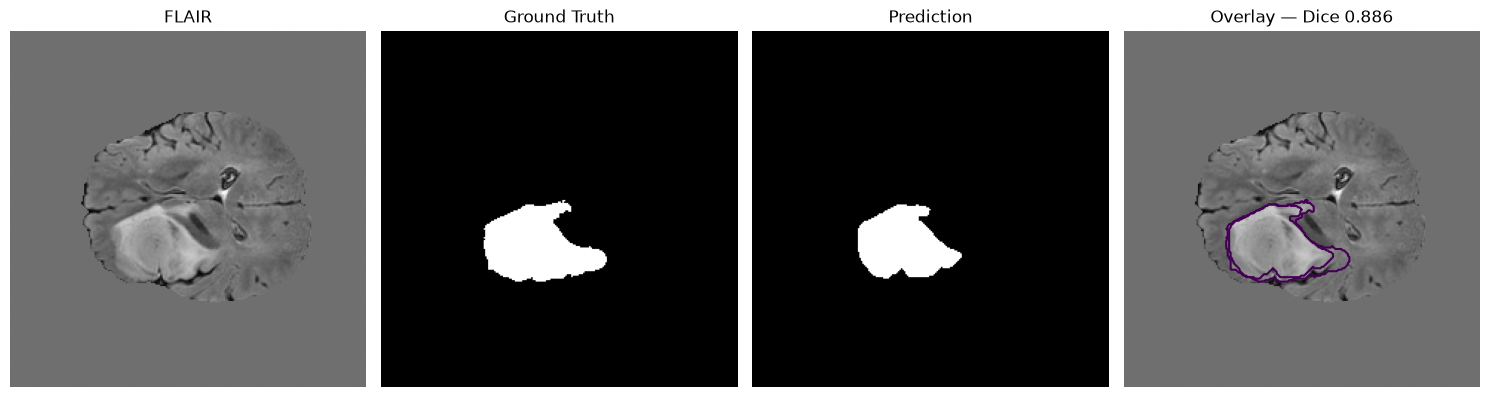

In [37]:
z_med = int(
    np.argmax(gt_med.sum(axis=(1, 2)))
)

fig = plt.figure(figsize=(15, 4))

images = [
    (mri_med[3, z_med], "FLAIR", "gray"),
    (gt_med[z_med], "Ground Truth", "gray"),
    (prediction_med[z_med], "Prediction", "gray"),
]

for i, (image, title, cmap) in enumerate(images, 1):
    ax = fig.add_subplot(1, 4, i)
    ax.imshow(image, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

ax = fig.add_subplot(1, 4, 4)

ax.imshow(
    mri_med[3, z_med],
    cmap="gray"
)

ax.contour(
    gt_med[z_med],
    levels=[0.5],
    linewidths=1.5
)

ax.contour(
    prediction_med[z_med],
    levels=[0.5],
    linewidths=1.5
)

ax.set_title(
    f"Overlay — Dice {median_dice:.3f}"
)

ax.axis("off")

plt.tight_layout()
plt.show()